In [75]:
!pip install mediapipe==0.10.20 --quiet
!pip install opencv-python-headless==4.10.0.84 --quiet
!pip install numpy pandas scikit-learn joblib tqdm --quiet


In [76]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [77]:
import os

root = "/content/drive/MyDrive"
for item in os.listdir(root):
    print(item)


Documents
Jk
Jk2
Untitled document (12).gdoc
Untitled document (11).gdoc
Untitled document.docx
Untitled document (10).gdoc
Colab Notebooks
112.jpg
,lll.jpg
Untitled document (9).gdoc
kkkkk_page-0001.jpg
Styrene Plant — Input ⇄ Output .gdoc
mba666 individual project.gdoc
core_resume_kavita.pdf
core
fee_recipt_placement.pdf
sde
This Kirana 2025 CPM India report.gdoc
Eco_friendly_plan_templet.gdoc
Untitled document (8).gdoc
Section 1.gdoc
make table how to put in ppt and in table just ri....gsheet
List of Countries by Sugarcane Production (1).csv
mba666_group_project.gdoc
Untitled document (7).gdoc
Here’s a 4–5 slide deck outline (ready to add to your “MBA Future Trends & Strategic Implementation” section) created by combining strategic insights from your mba666_group_project and mba.gdoc
placement.csv
Copy of placement.csv
Untitled document (6).gdoc
Main (1).cpp
Kavita_220512.gdoc
Untitled document (5).gdoc
Untitled document (4).gdoc
Untitled document (3).gdoc
Untitled spreadsheet.gshee

In [78]:
dataset_root = "/content/drive/MyDrive/sign_dataset"


In [79]:
import os

base = "/content/drive/MyDrive"

candidate = "sign_dataset"  # <-- change this
path = os.path.join(base, candidate)
print("Checking:", path)

for root, dirs, files in os.walk(path):
    print("ROOT:", root)
    print("  Subfolders:", dirs[:5])
    print("  Sample files:", files[:5])
    break  # just first level


Checking: /content/drive/MyDrive/sign_dataset
ROOT: /content/drive/MyDrive/sign_dataset
  Subfolders: ['hello', 'thanks', 'yes', 'no', 'iloveyou']
  Sample files: []


In [80]:
dataset_root = "THE_PATH_YOU_FOUND"
print("Using dataset_root:", dataset_root)


Using dataset_root: THE_PATH_YOU_FOUND


In [81]:
import cv2
import mediapipe as mp
import numpy as np
import pandas as pd
from tqdm import tqdm
import os

mp_hands = mp.solutions.hands

def extract_hand_landmarks_from_image(image_bgr):
    """
    Returns a flat list [x1,y1,z1,...,x21,y21,z21] if a hand is found,
    otherwise returns None.
    """
    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    with mp_hands.Hands(
        static_image_mode=True,
        max_num_hands=1,
        min_detection_confidence=0.5
    ) as hands:
        results = hands.process(image_rgb)
        if not results.multi_hand_landmarks:
            return None
        hand_landmarks = results.multi_hand_landmarks[0]
        data = []
        for lm in hand_landmarks.landmark:
            data.extend([lm.x, lm.y, lm.z])
        return data


dataset_root = "/content/drive/MyDrive/RealTimeObjectDetection/Tensorflow/workspace/images/collect_images"



columns = ['label'] + [f'{axis}{i}' for i in range(21) for axis in ['x', 'y', 'z']]
data_rows = []

labels = sorted([d for d in os.listdir(dataset_root)
                 if os.path.isdir(os.path.join(dataset_root, d))])

print("Found labels (subfolders):", labels)

for label in labels:
    label_dir = os.path.join(dataset_root, label)
    image_files = [f for f in os.listdir(label_dir)
                   if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

    print(f"\nProcessing label: {label}, images: {len(image_files)}")

    for img_name in tqdm(image_files):
        img_path = os.path.join(label_dir, img_name)
        img = cv2.imread(img_path)
        if img is None:
            continue

        landmarks = extract_hand_landmarks_from_image(img)
        if landmarks is not None:
            row = [label] + landmarks
            data_rows.append(row)

df = pd.DataFrame(data_rows, columns=columns)
print("Total valid samples (hand detected):", len(df))

csv_path = "/content/drive/MyDrive/sign_data_from_images.csv"
df.to_csv(csv_path, index=False)
print("Saved CSV to:", csv_path)
df.head()


Found labels (subfolders): ['hello', 'iloveyou', 'no', 'thanks', 'yes']

Processing label: hello, images: 15


100%|██████████| 15/15 [00:01<00:00,  7.78it/s]



Processing label: iloveyou, images: 16


100%|██████████| 16/16 [00:02<00:00,  7.08it/s]



Processing label: no, images: 15


...

100%|██████████| 19/19 [00:05<00:00,  3.23it/s]



Processing label: yes, images: 10


100%|██████████| 10/10 [00:01<00:00,  9.06it/s]


Total valid samples (hand detected): 72
Saved CSV to: /content/drive/MyDrive/sign_data_from_images.csv


,label,x0,y0,z0,x1,y1,z1,x2,y2,z2,...,z17,x18,y18,z18,x19,y19,z19,x20,y20,z20
0,hello,0.891490,0.679332,5.879669e-08,0.764374,0.750964,-0.025874,0.629737,0.750706,-0.029606,...,-0.027726,0.631251,0.231107,-0.047084,0.573211,0.182363,-0.056368,0.512394,0.145695,-0.064386
1,hello,0.892117,0.734928,3.469940e-08,0.779757,0.839248,-0.027857,0.625952,0.865729,-0.027836,...,-0.021796,0.558704,0.318252,-0.047344,0.486048,0.287877,-0.064172,0.412582,0.273227,-0.077207
2,hello,0.579024,0.782402,4.210895e-07,0.472648,0.785592,-0.024250,0.367457,0.717383,-0.030976,...,-0.042180,0.565665,0.289822,-0.063468,0.564262,0.205403,-0.076522,0.558700,0.130639,-0.085554
3,hello,0.320109,0.933560,6.390811e-07,0.405648,0.963336,-0.040242,0.502493,0.943654,-0.053198,...,-0.011248,0.410171,0.572586,-0.024366,0.430081,0.516767,-0.033519,0.453970,0.468823,-0.040120
4,hello,0.415274,0.764183,5.274226e-07,0.500290,0.812017,-0.029361,0.600222,0.803922,-0.033706,...,-0.001496,0.536372,0.427302,-0.009631,0.558227,0.379132,-0.014414,0.581570,0.339992,-0.017963


In [82]:
model_path = "/content/drive/MyDrive/sign_model_from_images.pkl"


In [83]:
from google.colab import drive
drive.mount('/content/drive')

import cv2
import mediapipe as mp
import numpy as np
import joblib
from google.colab.patches import cv2_imshow

# Load model
MODEL_PATH = "/content/drive/MyDrive/sign_model_from_images.pkl"
clf = joblib.load(MODEL_PATH)
print("Model loaded!")

mp_hands = mp.solutions.hands
mp_drawing = mp.solutions.drawing_utils

def extract_hand_landmarks(hand_landmarks):
    data = []
    for lm in hand_landmarks.landmark:
        data.extend([lm.x, lm.y, lm.z])
    return data

cap = cv2.VideoCapture(0)
if not cap.isOpened():
    print("Error: Could not open webcam.")
else:
    with mp_hands.Hands(
        static_image_mode=False,
        max_num_hands=1,
        min_detection_confidence=0.5,
        min_tracking_confidence=0.5
    ) as hands:

        current_pred = ""

        while True:
            ret, frame = cap.read()
            if not ret:
                print("Frame skipped")
                break

            frame = cv2.flip(frame, 1)
            img_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            results = hands.process(img_rgb)

            if results.multi_hand_landmarks:
                for hand_landmarks in results.multi_hand_landmarks:
                    mp_drawing.draw_landmarks(
                        frame,
                        hand_landmarks,
                        mp_hands.HAND_CONNECTIONS
                    )

                    features = extract_hand_landmarks(hand_landmarks)
                    features = np.array(features).reshape(1, -1)
                    pred = clf.predict(features)[0]
                    current_pred = pred

            cv2.putText(frame, f"Prediction: {current_pred}",
                        (10, 40), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 2)

            cv2_imshow(frame)
            key = cv2.waitKey(1) & 0xFF
            if key == ord('q'):
                break

cap.release()
cv2.destroyAllWindows()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Model loaded!
Error: Could not open webcam.


In [84]:
!pip install mediapipe opencv-python numpy joblib --quiet


In [85]:
from google.colab import output
from base64 import b64decode
from io import BytesIO
from PIL import Image
import numpy as np
import cv2

def use_webcam():
    js = Javascript('''
    async function takePhoto() {
      const div = document.createElement('div');
      document.body.appendChild(div);
      const video = document.createElement('video');
      video.style.display = 'block';
      div.appendChild(video);
      const stream = await navigator.mediaDevices.getUserMedia({ video: true });
      video.srcObject = stream;
      await video.play();

      google.colab.output.setMimeBundle("application/javascript", {"text/plain": ""});
      const canvas = document.createElement('canvas');
      canvas.width = video.videoWidth;
      canvas.height = video.videoHeight;
      canvas.getContext('2d').drawImage(video, 0, 0);
      stream.getTracks().forEach(track => track.stop());
      const data = canvas.toDataURL('image/jpeg', 0.8);
      google.colab.kernel.invokeFunction('notebook.takePhoto', [data], {});
    }
    takePhoto();
    ''')
    display(js)


In [86]:
photo_data = None

def take_photo_callback(data):
    global photo_data
    photo_data = data

output.register_callback('notebook.takePhoto', take_photo_callback)


In [87]:
from google.colab.output import eval_js
from IPython.display import Javascript, display


In [88]:
use_webcam()


<IPython.core.display.Javascript object>

In [89]:
from google.colab import output
from google.colab.output import eval_js
from IPython.display import Javascript, display
import cv2
import numpy as np
from base64 import b64decode
from io import BytesIO
from PIL import Image


In [90]:
def use_webcam():
    js = Javascript('''
    async function takePhoto() {
      const div = document.createElement('div');
      document.body.appendChild(div);
      const video = document.createElement('video');
      video.style.display = 'block';
      div.appendChild(video);
      const stream = await navigator.mediaDevices.getUserMedia({ video: true });
      video.srcObject = stream;
      await video.play();

      google.colab.output.setMimeBundle("application/javascript", {"text/plain": ""});
      const canvas = document.createElement('canvas');
      canvas.width = video.videoWidth;
      canvas.height = video.videoHeight;
      canvas.getContext('2d').drawImage(video, 0, 0);
      stream.getTracks().forEach(track => track.stop());
      const data = canvas.toDataURL('image/jpeg', 0.8);
      google.colab.kernel.invokeFunction('notebook.takePhoto', [data], {});
    }
    takePhoto();
    ''')
    display(js)


In [91]:
photo_data = None

def take_photo_callback(data):
    global photo_data
    photo_data = data

output.register_callback('notebook.takePhoto', take_photo_callback)


In [92]:
use_webcam()


<IPython.core.display.Javascript object>

In [93]:
def use_webcam():
    display(Javascript('''
    async function takePhoto() {
      const video = document.createElement('video');
      const stream = await navigator.mediaDevices.getUserMedia({video:true});
      video.srcObject = stream;
      document.body.appendChild(video);
      await video.play();

      const canvas = document.createElement('canvas');
      canvas.width = video.videoWidth;
      canvas.height = video.videoHeight;
      const context = canvas.getContext('2d');
      context.drawImage(video, 0, 0, video.videoWidth, video.videoHeight);

      stream.getTracks().forEach(track => track.stop());
      video.remove();

      const data = canvas.toDataURL('image/jpeg', 0.8);
      google.colab.kernel.invokeFunction('notebook.takePhoto', [data], {});
    }
    takePhoto();
    '''))


In [94]:
photo_data = None

def take_photo_callback(data):
    global photo_data
    photo_data = data
    print("Photo captured!")

output.register_callback('notebook.takePhoto', take_photo_callback)


In [95]:
use_webcam()


<IPython.core.display.Javascript object>

In [98]:
img = Image.open(BytesIO(b64decode(photo_data.split(',')[1])))
frame = np.array(img)


AttributeError: 'NoneType' object has no attribute 'split'

In [99]:
print(photo_data)


None


In [100]:
import mediapipe as mp
import joblib

MODEL_PATH = "/content/drive/MyDrive/sign_model_from_images.pkl"
clf = joblib.load(MODEL_PATH)

# Decode base64 → image
img = Image.open(BytesIO(b64decode(photo_data.split(',')[1])))
frame = np.array(img)

mp_hands = mp.solutions.hands

with mp_hands.Hands(static_image_mode=True) as hands:
    results = hands.process(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    if results.multi_hand_landmarks:
        data=[]
        for lm in results.multi_hand_landmarks[0].landmark:
            data.extend([lm.x,lm.y,lm.z])
        pred = clf.predict([data])[0]
        print("Prediction:", pred)
    else:
        print("No hand detected")


AttributeError: 'NoneType' object has no attribute 'split'

In [ ]:
from google.colab.output import eval_js
from IPython.display import Javascript, display
from base64 import b64decode
from io import BytesIO

from PIL import Image
import numpy as np
import cv2
import mediapipe as mp
import joblib

# Load your trained model
MODEL_PATH = "/content/drive/MyDrive/sign_model_from_images.pkl"   # <-- change if name is different
clf = joblib.load(MODEL_PATH)
print("Model loaded:", MODEL_PATH)

mp_hands = mp.solutions.hands


In [101]:
from google.colab.output import eval_js
from IPython.display import Javascript, display
from base64 import b64decode
from io import BytesIO

from PIL import Image
import numpy as np
import cv2
import mediapipe as mp
import joblib

MODEL_PATH = "/content/drive/MyDrive/sign_model_from_images.pkl"
clf = joblib.load(MODEL_PATH)
print("Model loaded.")


Model loaded.


In [102]:
js = Javascript('''
  async function takePhoto() {
    const video = document.createElement('video');
    const stream = await navigator.mediaDevices.getUserMedia({video:true});
    video.srcObject = stream;
    document.body.appendChild(video);
    await video.play();

    // give time to pose your sign
    await new Promise(resolve => setTimeout(resolve, 1500));

    const canvas = document.createElement('canvas');
    canvas.width = video.videoWidth;
    canvas.height = video.videoHeight;
    const ctx = canvas.getContext('2d');
    ctx.drawImage(video, 0, 0);

    stream.getTracks().forEach(t => t.stop());
    video.remove();

    return canvas.toDataURL('image/jpeg', 0.9);
  }
''')
display(js)


<IPython.core.display.Javascript object>

In [103]:
import cv2
import mediapipe as mp
import numpy as np
import joblib

MODEL_PATH =  "/content/drive/MyDrive/sign_model_from_images.pkl"  # your saved model

clf = joblib.load(MODEL_PATH)
print("Model loaded!")

mp_hands = mp.solutions.hands
mp_drawing = mp.solutions.drawing_utils

def extract_hand_landmarks(hand_landmarks):
    data = []
    for lm in hand_landmarks.landmark:
        data.extend([lm.x, lm.y, lm.z])
    return data

def main():
    cap = cv2.VideoCapture(0)

    if not cap.isOpened():
        print("Could not open webcam.")
        return

    with mp_hands.Hands(
        static_image_mode=False,
        max_num_hands=1,
        min_detection_confidence=0.5,
        min_tracking_confidence=0.5
    ) as hands:

        current_pred = ""

        while True:
            ret, frame = cap.read()
            if not ret:
                print(" Failed to grab frame.")
                break

            frame = cv2.flip(frame, 1)
            img_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            results = hands.process(img_rgb)

            if results.multi_hand_landmarks:
                for hand_landmarks in results.multi_hand_landmarks:
                    mp_drawing.draw_landmarks(frame, hand_landmarks, mp_hands.HAND_CONNECTIONS)

                    features = extract_hand_landmarks(hand_landmarks)
                    features = np.array(features).reshape(1, -1)
                    pred = clf.predict(features)[0]
                    current_pred = pred

            cv2.putText(frame, f"Predicted: {current_pred}", (10, 30),
                        cv2.FONT_HERSHEY_SIMPLEX, 1, (0,0,255), 2)

            cv2.imshow("Live Sign Detection", frame)

            if cv2.waitKey(1) & 0xFF == ord('q'):
                break

    cap.release()
    cv2.destroyAllWindows()

if __name__ == "__main__":
    main()


Model loaded!
Could not open webcam.


In [104]:
from google.colab.output import eval_js
from IPython.display import Javascript, display
from base64 import b64decode
from io import BytesIO

from PIL import Image
import numpy as np
import cv2
import mediapipe as mp
import joblib

MODEL_PATH = "/content/drive/MyDrive/sign_model_from_images.pkl"  # modify if needed
clf = joblib.load(MODEL_PATH)
print("Model loaded.")


Model loaded.


In [105]:
js = Javascript('''
async function captureFrame() {
  const video = document.createElement('video');
  const stream = await navigator.mediaDevices.getUserMedia({video:true});
  video.srcObject = stream;
  document.body.appendChild(video);
  await video.play();

  // Give the user a moment to pose
  await new Promise(resolve => setTimeout(resolve, 700));

  const canvas = document.createElement('canvas');
  canvas.width = video.videoWidth;
  canvas.height = video.videoHeight;
  canvas.getContext('2d').drawImage(video, 0, 0);

  stream.getTracks().forEach(t => t.stop());
  video.remove();

  return canvas.toDataURL('image/jpeg', 0.9);
}
''')
display(js)


<IPython.core.display.Javascript object>

In [106]:
from google.colab.output import eval_js
from IPython.display import Javascript, display


In [107]:
js = Javascript('''
async function captureFrame() {
  const video = document.createElement('video');
  const stream = await navigator.mediaDevices.getUserMedia({video:true});
  video.srcObject = stream;
  document.body.appendChild(video);
  await video.play();

  await new Promise(resolve => setTimeout(resolve, 800));

  const canvas = document.createElement('canvas');
  canvas.width = video.videoWidth;
  canvas.height = video.videoHeight;
  canvas.getContext('2d').drawImage(video, 0, 0);

  stream.getTracks().forEach(t => t.stop());
  video.remove();

  return canvas.toDataURL('image/jpeg', 0.9);
}
''')
display(js)


<IPython.core.display.Javascript object>

In [110]:
from google.colab import drive
drive.mount('/content/drive')

from google.colab.output import eval_js
from base64 import b64decode
from io import BytesIO

from PIL import Image
import numpy as np
import cv2
import mediapipe as mp
import joblib

# 🔁 use the same model you trained in this notebook
MODEL_PATH = "/content/drive/MyDrive/sign_model_from_images.pkl"
clf = joblib.load(MODEL_PATH)
print("✅ Model loaded from:", MODEL_PATH)

mp_hands = mp.solutions.hands


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Model loaded from: /content/drive/MyDrive/sign_model_from_images.pkl


📸 Frame captured!


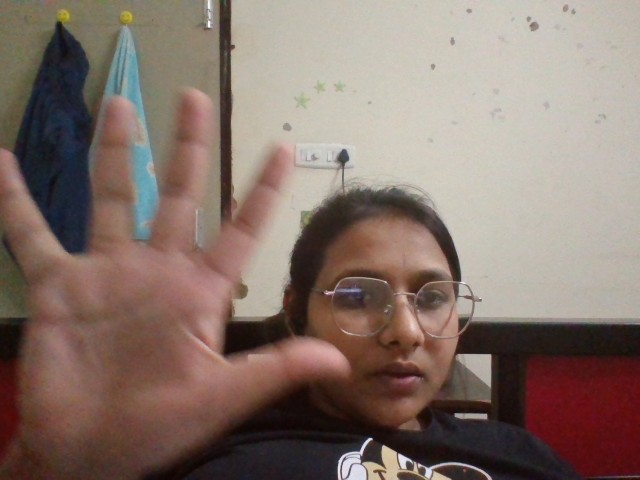

🖐 Predicted sign: hello


In [120]:
# 1) Capture a frame from the browser webcam using inline JS
js_code = """
  async function takeAndReturn() {
    const stream = await navigator.mediaDevices.getUserMedia({video:true});
    const video = document.createElement('video');
    video.srcObject = stream;
    await video.play();

    // Wait a bit so you can pose your sign
    await new Promise(r => setTimeout(r, 800));

    const canvas = document.createElement('canvas');
    canvas.width = video.videoWidth;
    canvas.height = video.videoHeight;
    const ctx = canvas.getContext('2d');
    ctx.drawImage(video, 0, 0);

    // Stop camera
    stream.getTracks().forEach(t => t.stop());
    video.remove();

    return canvas.toDataURL('image/jpeg', 0.9);
  }
  takeAndReturn();
"""

data_url = eval_js(js_code)
print("📸 Frame captured!")

# 2) Decode the data URL → image array
header, encoded = data_url.split(",", 1)
img_bytes = b64decode(encoded)
img = Image.open(BytesIO(img_bytes))
frame = np.array(img)  # RGB

# 3) (Optional) show the captured frame
from google.colab.patches import cv2_imshow
cv2_imshow(cv2.cvtColor(frame, cv2.COLOR_RGB2BGR))

# 4) Run Mediapipe Hands on this frame and predict using your model
with mp_hands.Hands(static_image_mode=True, max_num_hands=1) as hands:
    results = hands.process(cv2.cvtColor(frame, cv2.COLOR_RGB2BGR))

    if results.multi_hand_landmarks:
        hand_landmarks = results.multi_hand_landmarks[0]

        # same feature style as in your training: 21 landmarks × (x, y, z)
        features = []
        for lm in hand_landmarks.landmark:
            features.extend([lm.x, lm.y, lm.z])

        pred = clf.predict([features])[0]
        print("🖐 Predicted sign:", pred)
    else:
        print("⚠️ No hand detected in the captured frame.")
